# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA & DLinear 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1. 시계열 데이터에 대해서 미래의 데이터를 예측하기 위해서는 과거의 데이터가 유지되는 지, 계속 변동하는 상태인 지가 중요하다. 왜냐하면 이러한 정상성(stationarity)을 기반으로 했을 때, 안정적으로 데이터를 모델링하여 미래의 데이터를 예측할 수 있기 때문이다.<br>
ARIMA 모델은 정상성 데이터를 전제로 한다. 따라서 수집한 데이터가 비정상성을 띈다면, 이를 차분이나 로그 변화를 통해서 정상성 데이터로 변환할 수 있다. ARIMA 모델은 이러한 방식으로 비정상성을 띄는 데이터를 정상성 데이터로 변환한 수 시계열 분석에 사용한다.

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2.원 시계열의 ACF가 천천히 감소하므로 이 시계열은 비정상에 속한다. 1차 차분 후에는 1차 차분을 거친 데이터의 ACF가 절단 형태를 띄므로 1차 차분 후에는 정상성을 띄고, PCAF는 서서히 감소하므로 이동 평균 모델에 적용할 수 있다. 따라서 p=0, d=1의 값을 갖는 ARIMA(0, 1, q) 모형을 사용할 수 있다.

## 실습

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)입니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [9]:
# kaggle 데이터 로드
import os

path = "/content/kaggle/input"
print(os.listdir(path))

['Summary_of_Weather.csv', 'Weather_Station_Locations.csv']


In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

In [11]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_df = pd.read_csv("/content/kaggle/input/Weather_Station_Locations.csv")
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [12]:
# station별 실제 날씨 데이터
weather_df = pd.read_csv("/content/kaggle/input/Summary_of_Weather.csv")

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_246/113546791.py:2: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("/content/kaggle/input/Summary_of_Weather.csv")


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

*대부분의 코드가 기온 예측으로 되어있어서 기온으로 예측한 결과를 바탕으로 과제를 진행하였습니다.*

In [13]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_246/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_246/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


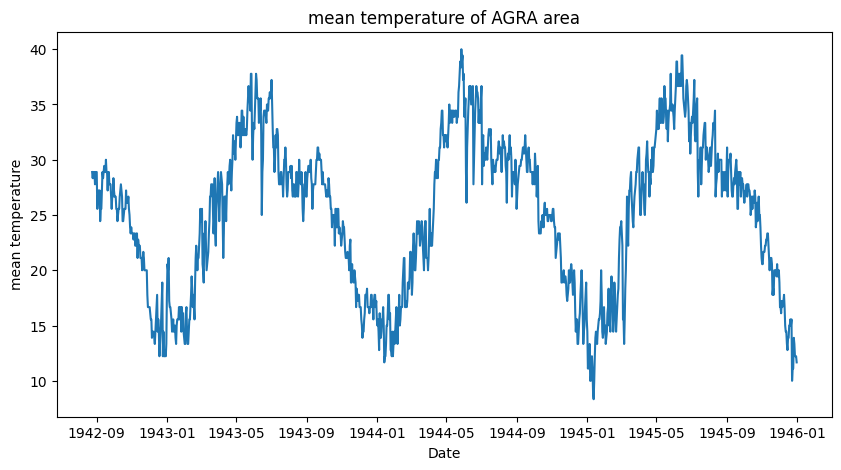

In [14]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("mean temperature")
plt.show()

In [15]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

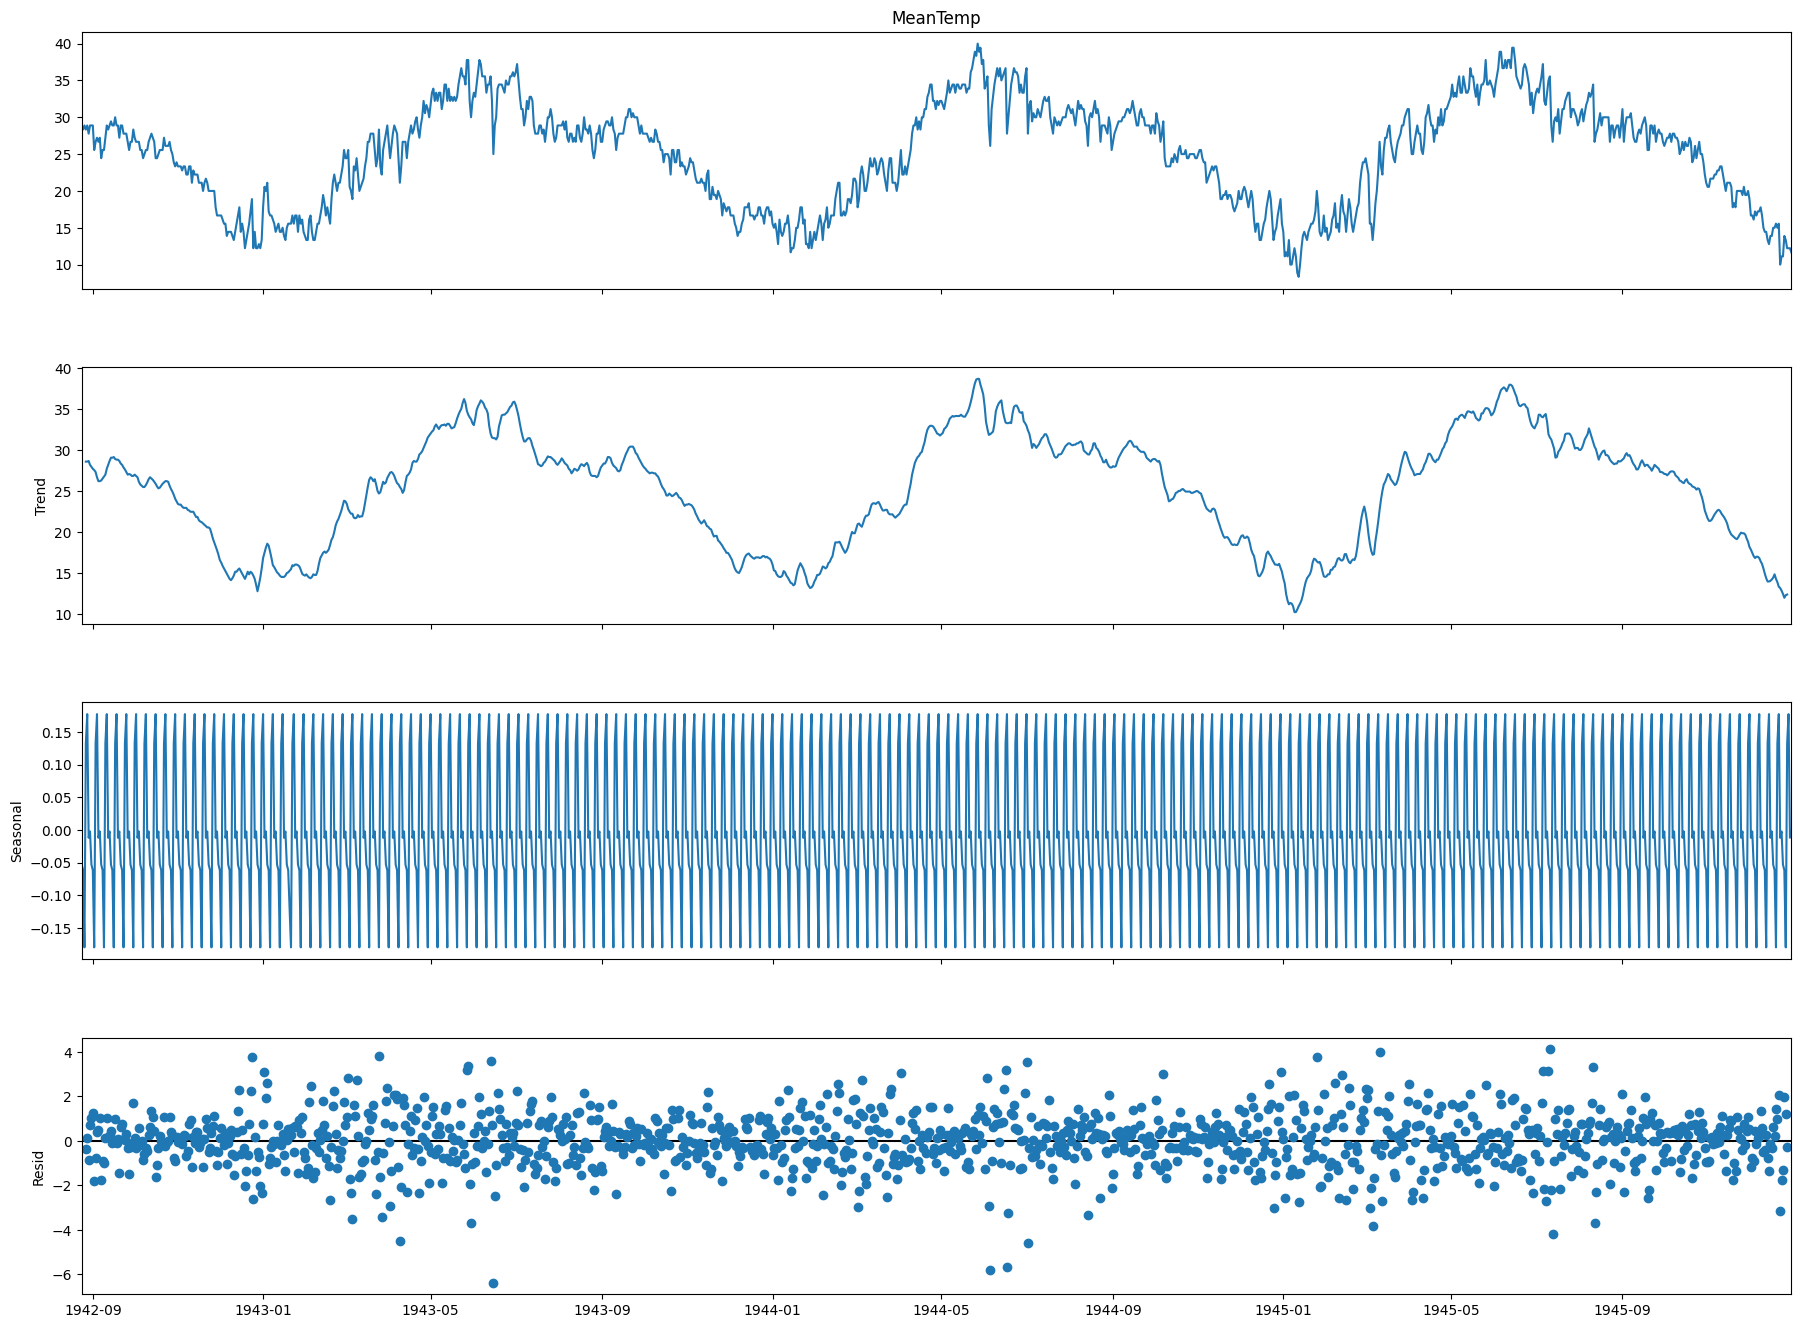

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

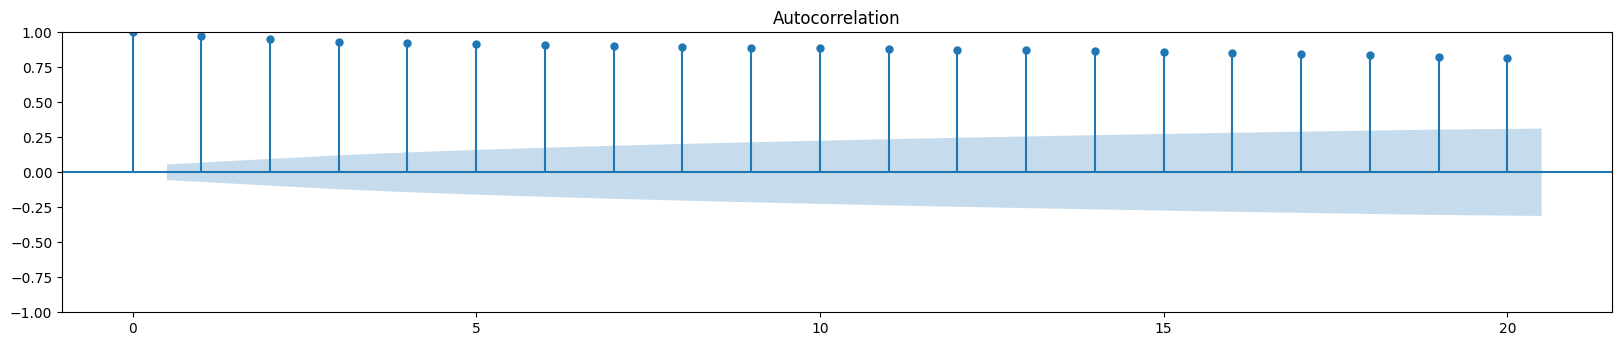

In [17]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [18]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.

A1. 현재 진행중인 ADF 검정에서 대립가설과 귀무가설은 다음과 같다.<br>
귀무가설: 데이터에 단위근이 존재한다. 즉, 시계열이 정상성을 나타내지 않는다.<br>
대립가설: 데이터에 단위근이 존재하지 않는다. 즉, 시계열이 정상성을 나타낸다.<br> p-value 값이 0.259885로 일반적인 유의수준 0.05보다 크고, ADF 통계량이 임계값보다 크다. 따라서 현재 데이터는 귀무가설을 기각하지 못한다. 즉, 이 시계열 데이터는 비정상 상태라는 것을 알 수 있다.<br>
그래프를 보았을 때, Seasonal(계절성)이 반복된다는 사실도 더불어 알 수 있다.

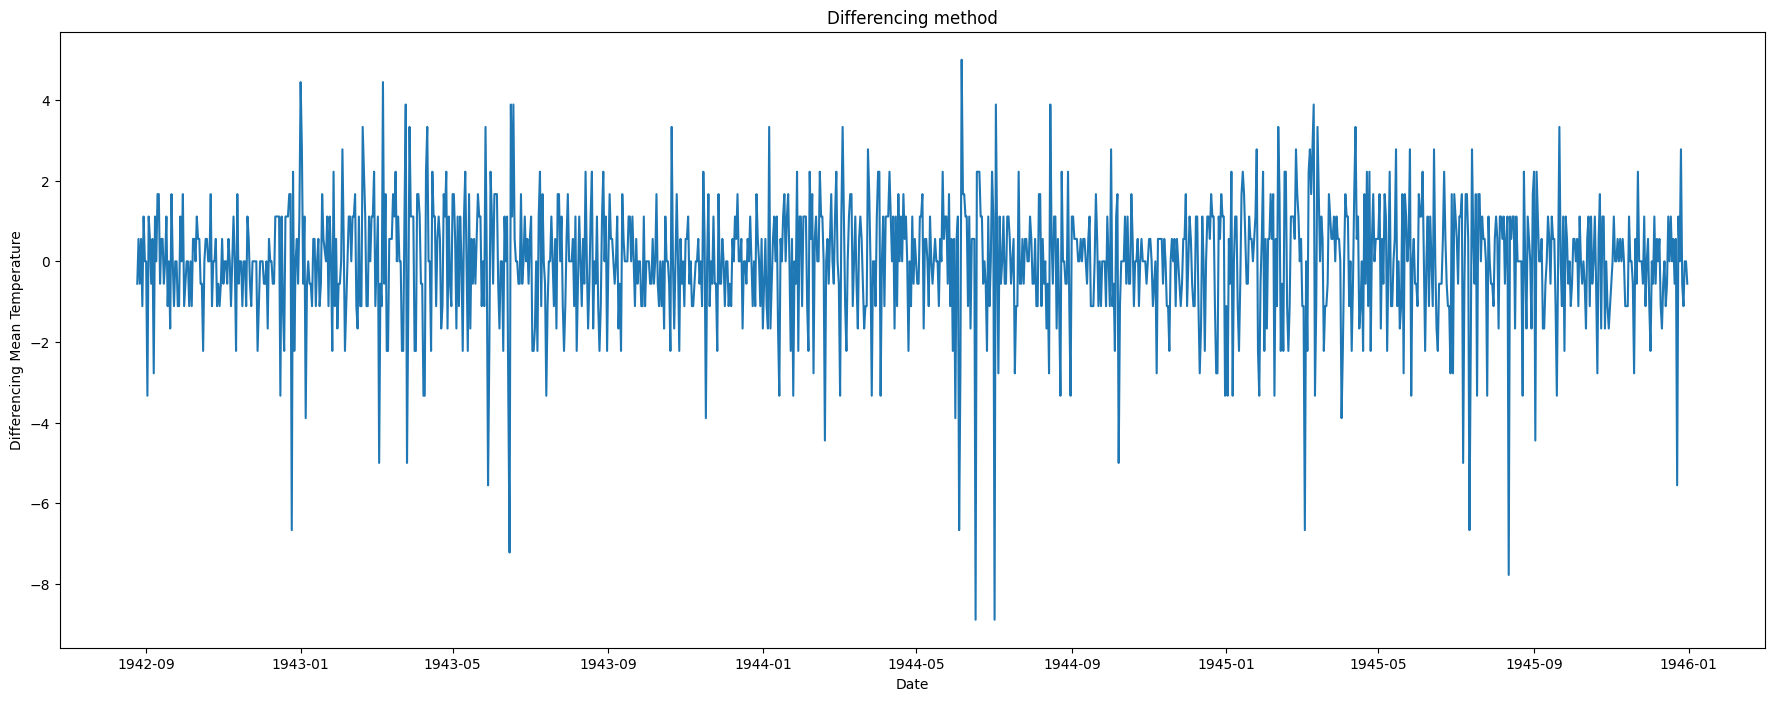

In [19]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [20]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2. 위 코드를 통해서 1차 차분을 진행한 결과, 1차 차분한 결과의 p-value는 0.000000으로 유의수준보다 작아졌음을 확인할 수 있다. 따라서 비정상성이라는 귀무가설을 기각할 수 있게 되었고, mean temperature 그래프가 0을 중심으로 분포가는 것으로 변화하였다.<br>
이렇게 변화한 이유는 차분 결과 데이터의 추세와 계절성이 제거되었고, 통계적 특성을 시간과 무관하게 일정하게 만들어져서 변화량만 남았기 떄문이다.

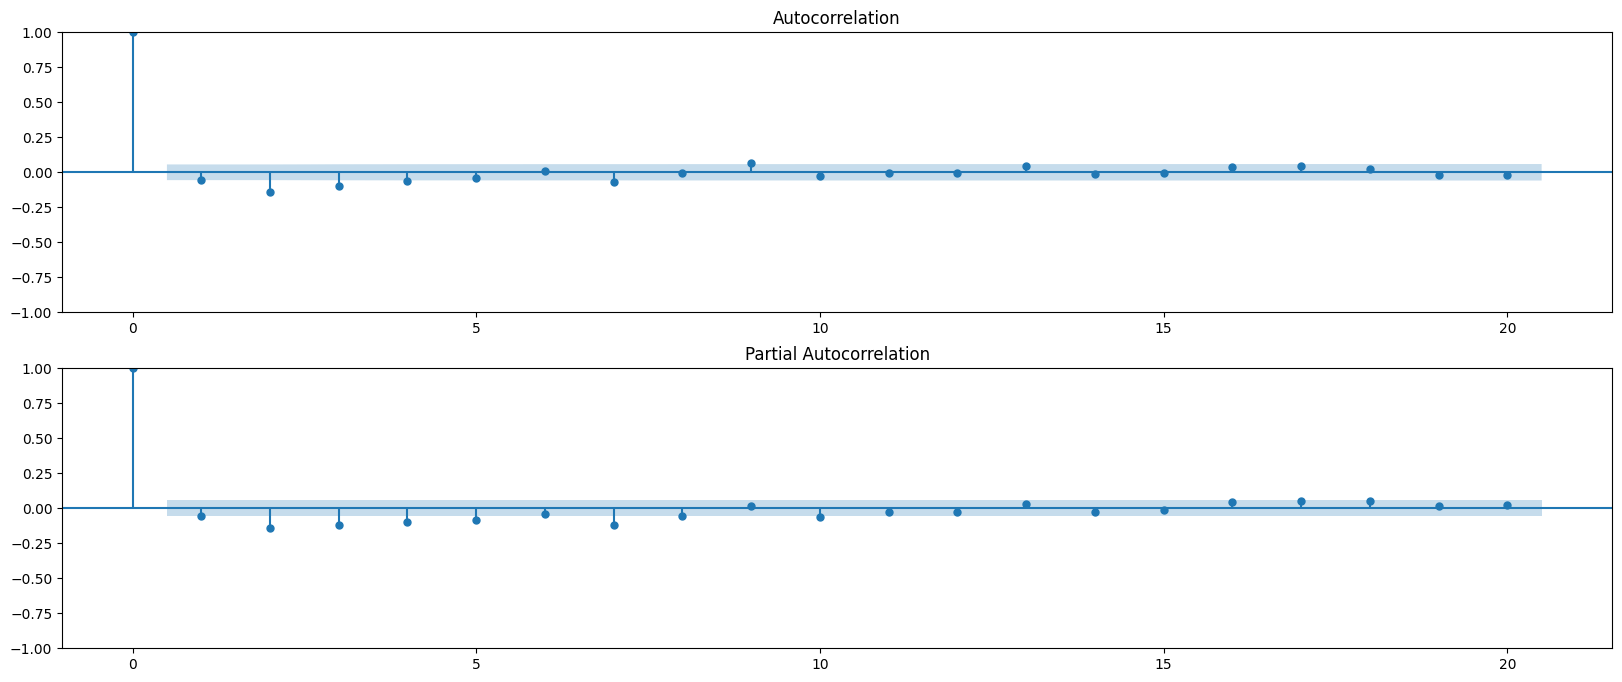

In [21]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3. Autocorrelation(ACF) 그래프의 결과 신뢰구간인 파란색 영역을 크게 벗어나는 값이 없고, 점차 그 값이 0에 수렴하고 있으므로 유의미한 상관관계가 발견되지 않았다. 따라서 q=0으로 설정할 수 있다.<br>
Partial Autocorrelation(PACF) 그래프의 결과 역시 신뢰구간인 파란색 영역을 크게 벗어나지 않기 떄문에 p=0으로 설정할 수 있다.<br>
따라서 p=0, q=0으로 변수를 설정했다. 1차 차분한 결과가 이 값이므로, d=1로 변수를 설정했다.

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


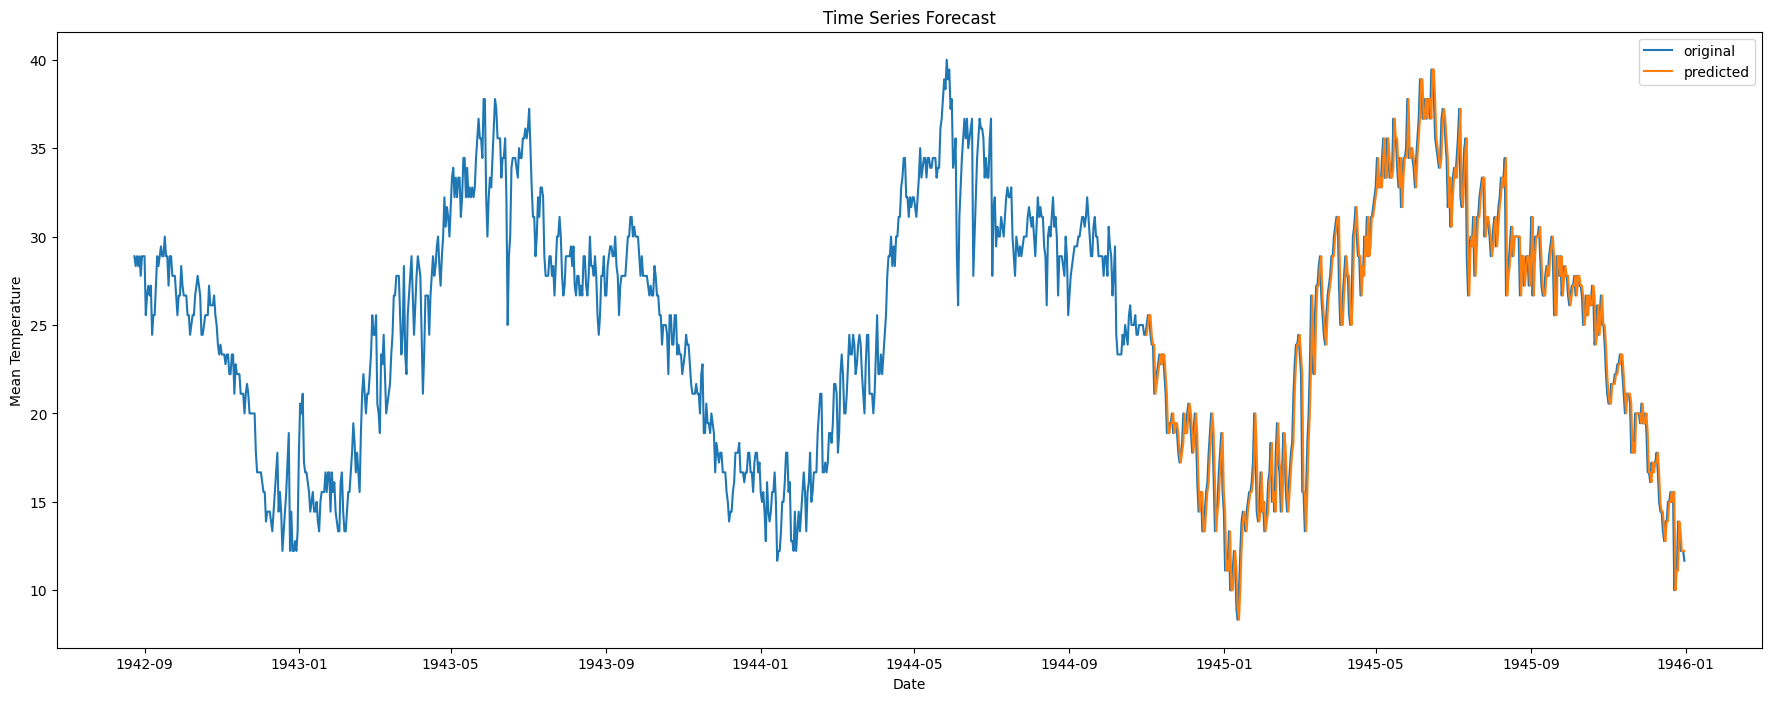

In [22]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 0
d = 1
q = 0

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_246/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


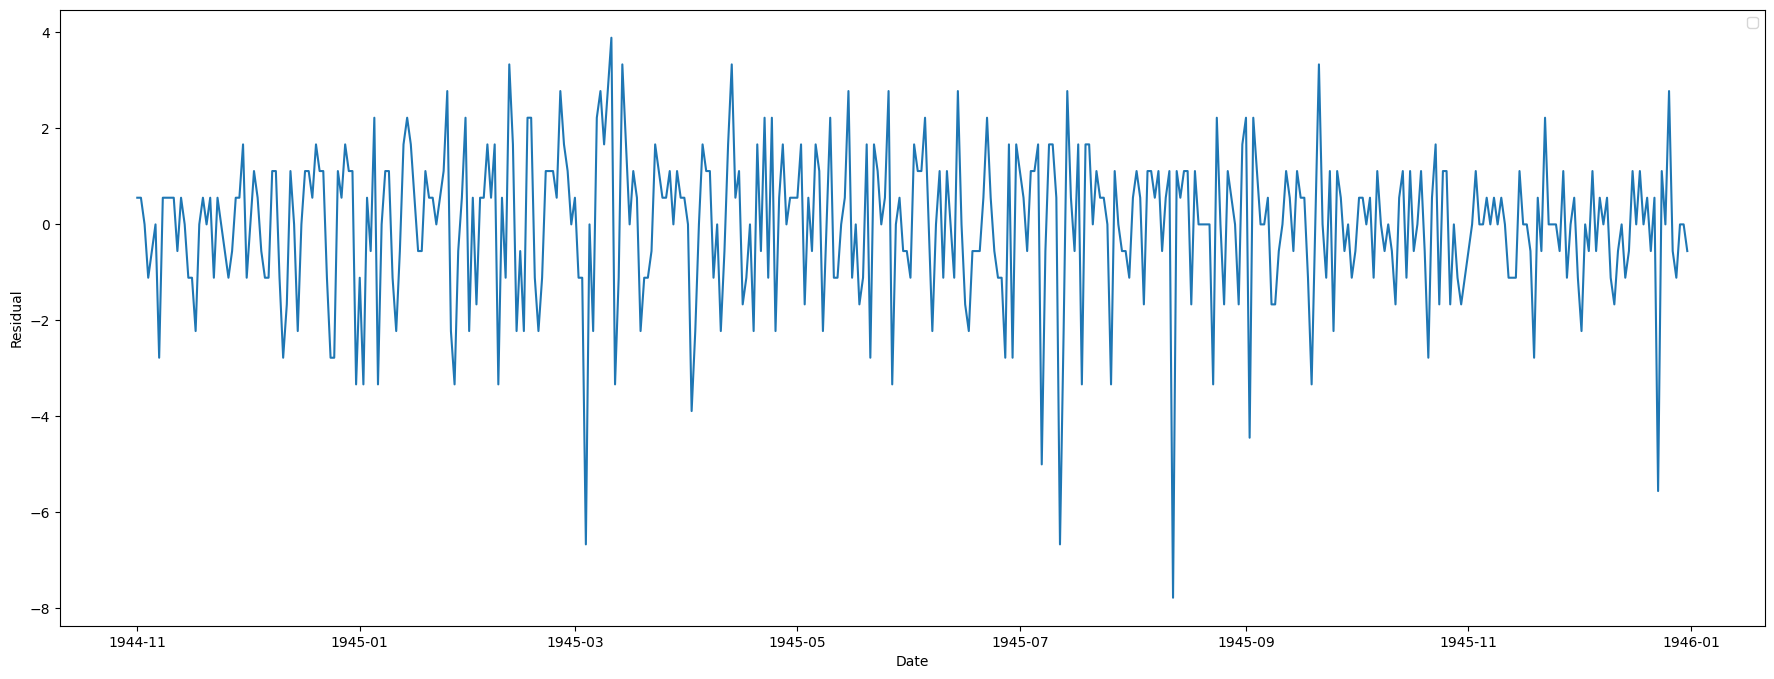

In [23]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

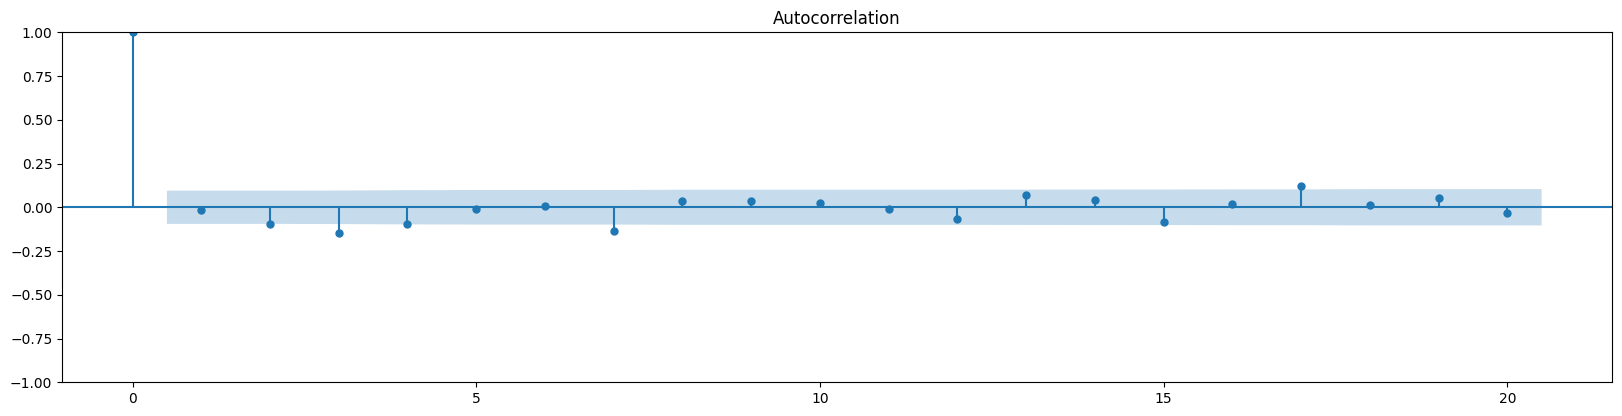

In [24]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [25]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.375983
p-value: 0.000000
Critical Values:
	1%: -3.446
	5%: -2.868
	10%: -2.570


In [26]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [27]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.56,0.978,1.565,5.366


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4. ADF test 결과 p-value가 0.000000이라는 것은 귀무가설이 0에 수렴한다는 것을 의미한다. 또한, 잔차분석에서 ACF 그래프의 대부분의 값이 대부분 신뢰구간 내에 속하므로 잔차 내에 상관관계가 없음을 확인할 수 있다.<br>
따라서 이 결과는 ARIMA(0, 1, 0) 모델이 AGRA 지역의 기온 데이터를 잘 학습하였음을 의미한다.

### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4.<br>
첫 번째 학습은 다음과 같이 매개변수를 설정하였다.<br>
kernel=365, epochs = 10, lr=0.01, seq_len = 365, pred_len = 30<br>
결과는 다음과 같다.<br>
R2: 72.632, Corr: 0.873, RMSE: 3.612, MAPE: 10.898<br><hr>

kernel의 사이즈를 1년 단위보다 줄이고 lr과 epoch의 수를 조정해 보았다.<br>
kernel=51, epochs = 100, lr=0.001, seq_len = 365, pred_len = 30<br>
결과는 다음과 같았다.<br>
R2: 78.625,	Corr: 0.907,	RMSE: 3.192,	MAPE: 10.136<br>
R2값이 눈에 띄게 늘고, RMSE 값도 개선되었지만 여전히 ARIMA에 비하면 못미치는 정도였다.<br><hr>

이번에는 예측을 위해 참조하는 seq_len을 줄이며 최적의 seq_len 값을 찾고자 했는데 결과적으로 seq_len이 180일 때가 90일 때 보다 훨씬 결과가 좋았기 때문에 180을 최적으로 삼아 실험을 계속 진행했다.<br>
kernel=51, epochs = 100, lr=0.001, seq_len = 180, pred_len = 30<br>
결과는 다음과 같았다.<br>
R2: 80.413,	Corr: 0.926,	RMSE: 3.055,	MAPE: 9.212<br><hr>

kernel_size를 조금 더 줄여보았지만 결과가 좋지 않아서 kernel은 51로 유지하고 epoch 수를 더 늘려보았다.<br><hr>
kernel=51, epochs = 150, lr=0.001, seq_len = 180, pred_len = 30<br>
결과는 다음과 같았다.<br>
R2:83.362,	Corr: 0.914,	RMSE: 2.816,	MAPE: 8.905<br><hr>

lr과 epoch 수를 다시 조정해보았다.<br>
kernel=51, epochs = 500, lr=0.0001, seq_len = 180, pred_len = 30<br>
**R2: 83.813,	Corr:0.928,	RMSE:2.778,	MAPE: 8.627**<br>

위 결과가 가장 좋은 결과라고 생각했다. 왜냐하면 R2 값도 가장 좋았고, RMSE값도 가장 작은 축에 속하기 때문이다. 이 결과는 데이터에 대하여 비교적 적합한 커널과 매개변수를 통해서 낮은 learning rate로 오랜 학습을 했기 때문에 튀는 학습 없이 안정적인 학습이 가능했기 때문이라고 생각한다.<br><br>
또한, 현재 데이터셋에 대해서는 ARIMA 모델이 DLinear 모델보다 훨씬 성능이 좋다고 생각한다. 왜냐하면 ARIMA는 지금과 같이 기온 하나만을 예측하는 단변량 데이터에 대해서는 비교적 연속성이 강한 데이터에 대하여 특히 더 잘 동작하기 때문이다.

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [29]:
data = ts.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [30]:
seq_len = 180 #365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [31]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=31):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [32]:
model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 500

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.028963
Epoch 20, Loss: 0.017057
Epoch 30, Loss: 0.013697
Epoch 40, Loss: 0.011878
Epoch 50, Loss: 0.010568
Epoch 60, Loss: 0.009901
Epoch 70, Loss: 0.009281
Epoch 80, Loss: 0.008654
Epoch 90, Loss: 0.008187
Epoch 100, Loss: 0.007953
Epoch 110, Loss: 0.007642
Epoch 120, Loss: 0.007493
Epoch 130, Loss: 0.007392
Epoch 140, Loss: 0.007256
Epoch 150, Loss: 0.007107
Epoch 160, Loss: 0.006995
Epoch 170, Loss: 0.006874
Epoch 180, Loss: 0.006843
Epoch 190, Loss: 0.006784
Epoch 200, Loss: 0.006680
Epoch 210, Loss: 0.006673
Epoch 220, Loss: 0.006580
Epoch 230, Loss: 0.006632
Epoch 240, Loss: 0.006599
Epoch 250, Loss: 0.006511
Epoch 260, Loss: 0.006429
Epoch 270, Loss: 0.006382
Epoch 280, Loss: 0.006357
Epoch 290, Loss: 0.006323
Epoch 300, Loss: 0.006429
Epoch 310, Loss: 0.006331
Epoch 320, Loss: 0.006382
Epoch 330, Loss: 0.006307
Epoch 340, Loss: 0.006378
Epoch 350, Loss: 0.006196
Epoch 360, Loss: 0.006201
Epoch 370, Loss: 0.006243
Epoch 380, Loss: 0.006309
Epoch 390, Loss: 0.00

In [33]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

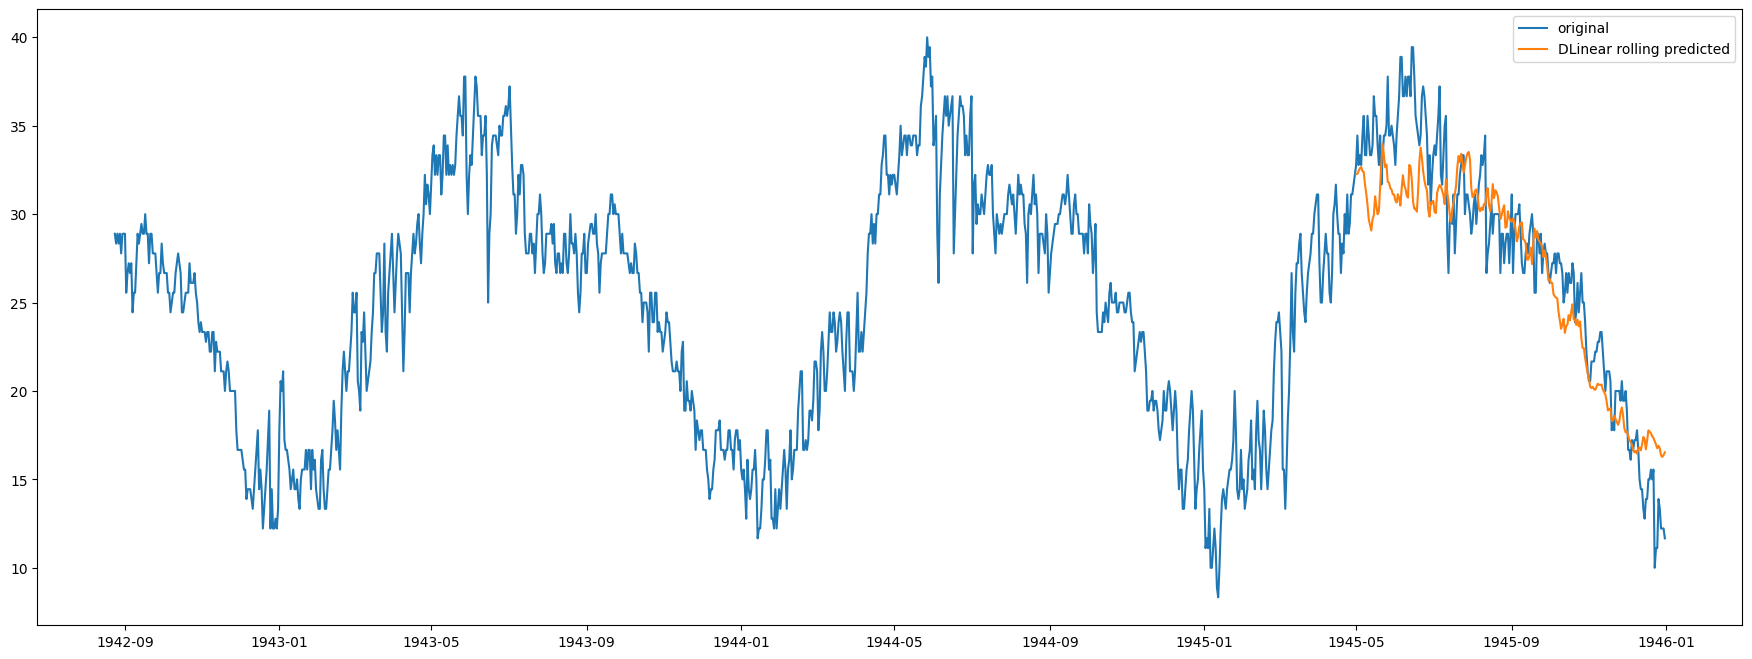

In [34]:
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")

test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [35]:
test_start_idx = train_size

y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(245,) (245,)


,R2,Corr,RMSE,MAPE
0,82.226,0.923,2.911,9.121


## 추가실습

- AGRA 지역의 기온 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [36]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
AMBERLY,848
AMURI/FIELD AAF,884
ATAR,876
...,...
TINDOUF,818
VAL DE CANS,1188
WALLER/BWI,1631


In [44]:
# 데이터가 가장 많은 ACCRA 지역의 Precip(강수) 예측으로 선정
loc_sta2 = loc_df[loc_df["NAME"] == "ACCRA"].WBAN
weather_bin2 = weather_df[weather_df.STA == int(loc_sta2)]
weather_bin2["Date"] = pd.to_datetime(weather_bin2["Date"])
weather_bin2

/tmp/ipykernel_246/3768716071.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin2 = weather_df[weather_df.STA == int(loc_sta2)]
/tmp/ipykernel_246/3768716071.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin2["Date"] = pd.to_datetime(weather_bin2["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-07-01,25.555556,22.222222,23.888889,1.016
1,10001,1942-07-02,28.888889,21.666667,25.555556,0.000
2,10001,1942-07-03,26.111111,22.222222,24.444444,2.540
3,10001,1942-07-04,26.666667,22.222222,24.444444,2.540
4,10001,1942-07-05,26.666667,21.666667,24.444444,0.000
...,...,...,...,...,...,...
1152,10001,1945-08-27,28.333333,22.777778,25.555556,0.100
1153,10001,1945-08-28,27.222222,22.222222,24.444444,13.970
1154,10001,1945-08-29,26.111111,22.222222,24.444444,3.048
1155,10001,1945-08-30,27.777778,22.777778,25.555556,0.100


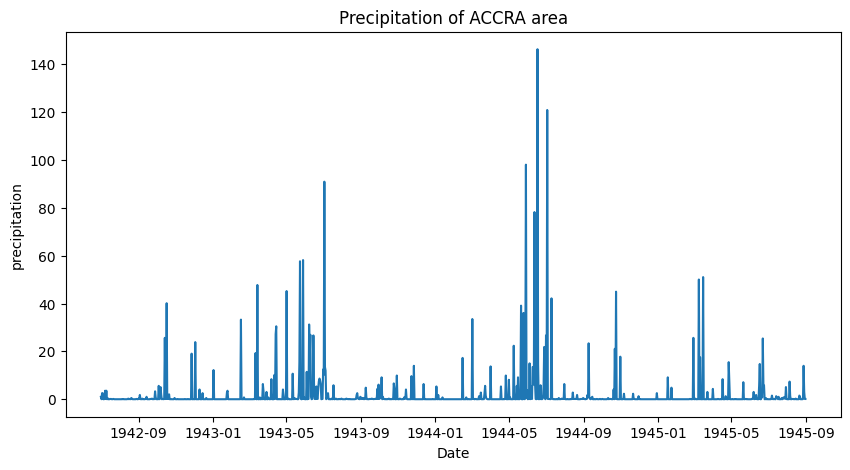

In [45]:
# 해당 지역의 강수량
plt.figure(figsize=(10, 5))
plt.plot(weather_bin2.Date, weather_bin2.Precip)
plt.title("Precipitation of ACCRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [47]:
timeSeries2 = weather_bin2.loc[:, ["Date", "Precip"]]
timeSeries2.index = timeSeries2.Date
ts2 = timeSeries2.drop("Date", axis=1)
ts2

,Precip
Date,
1942-07-01,1.016
1942-07-02,0.000
1942-07-03,2.540
1942-07-04,2.540
1942-07-05,0.000
...,...
1945-08-27,0.100
1945-08-28,13.970
1945-08-29,3.048


<Figure size 640x480 with 0 Axes>

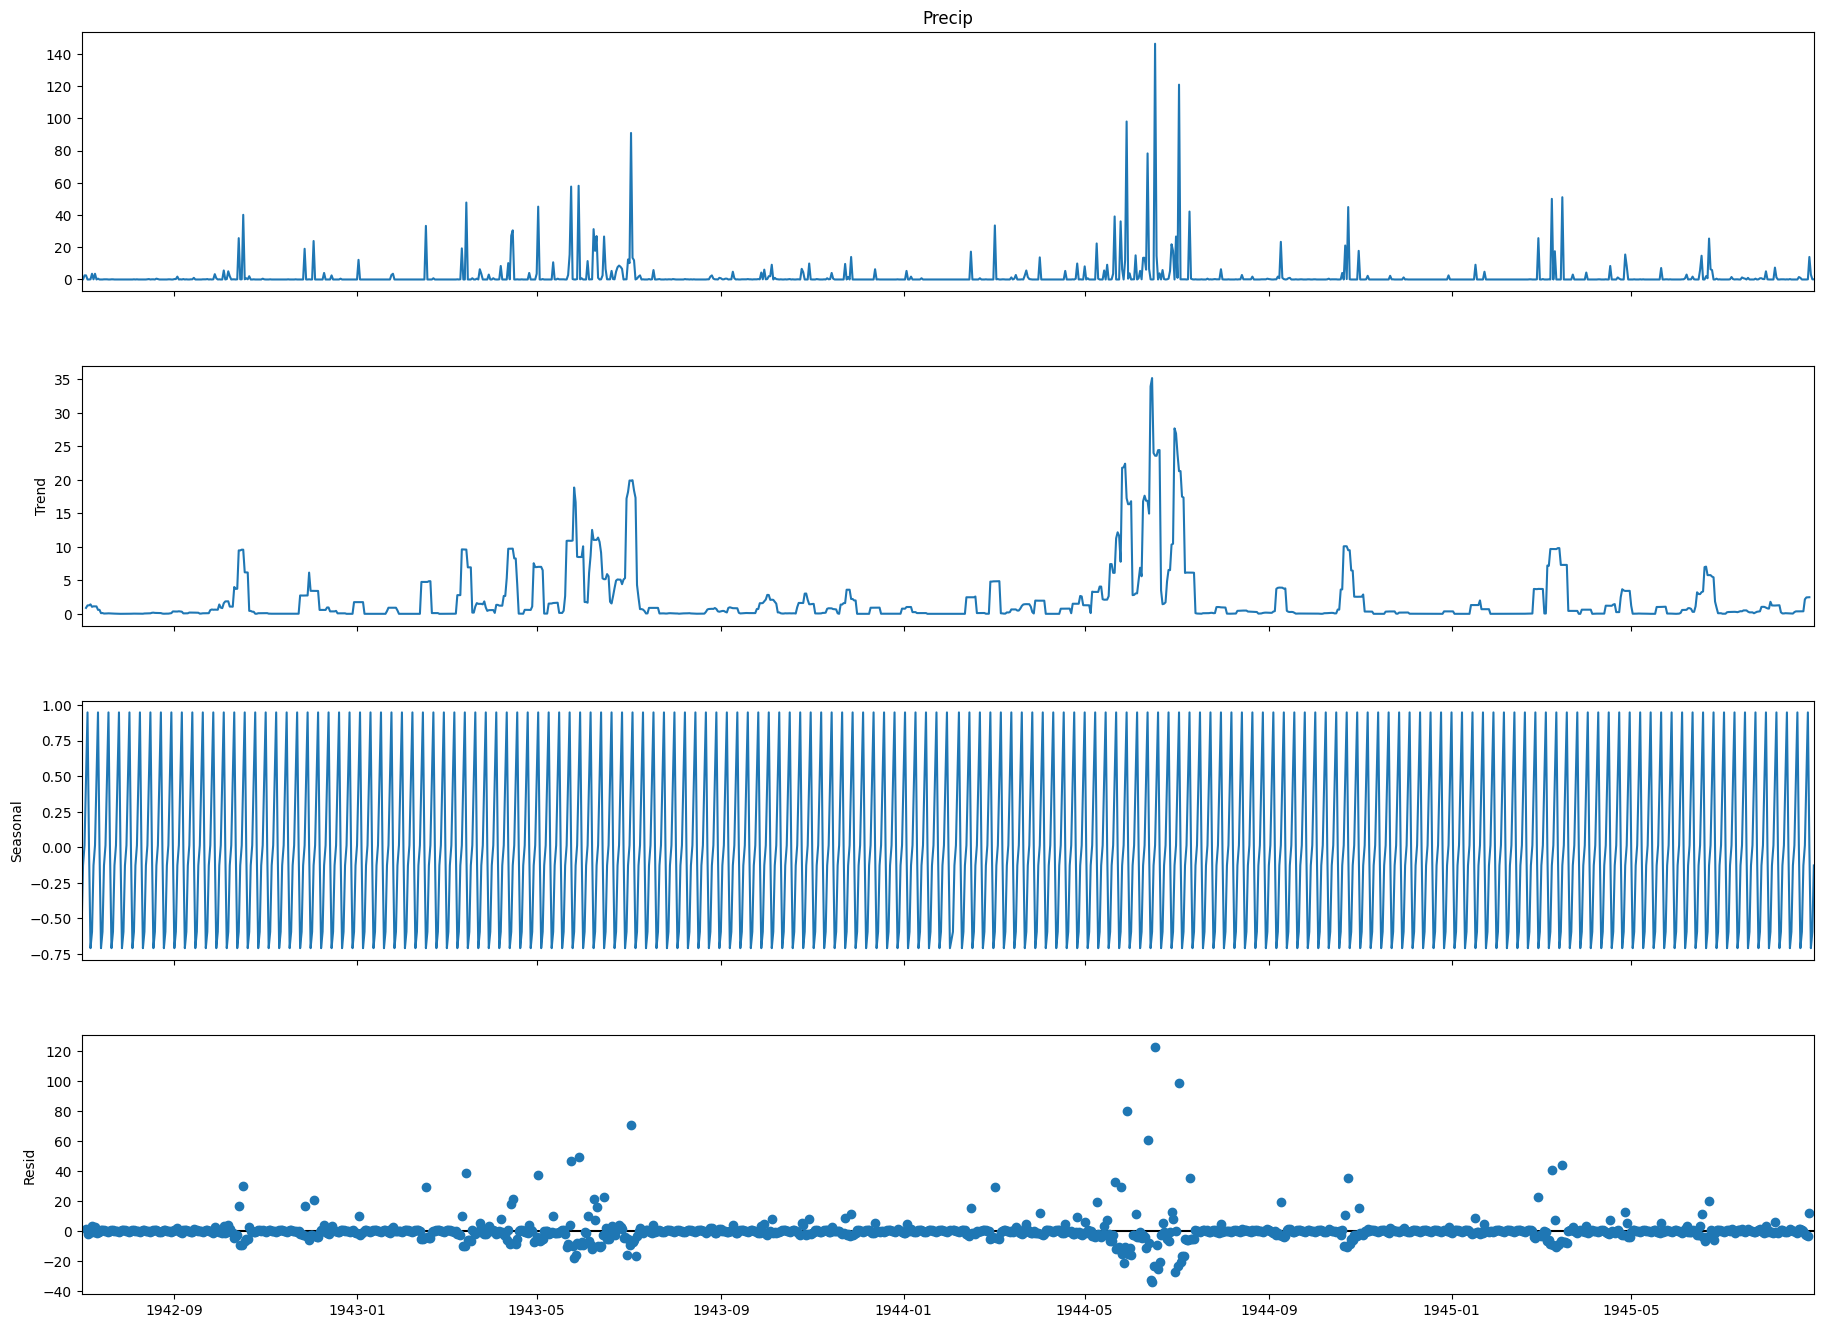

In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose

#시계열 구성요소별 분리
result = seasonal_decompose(ts2["Precip"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

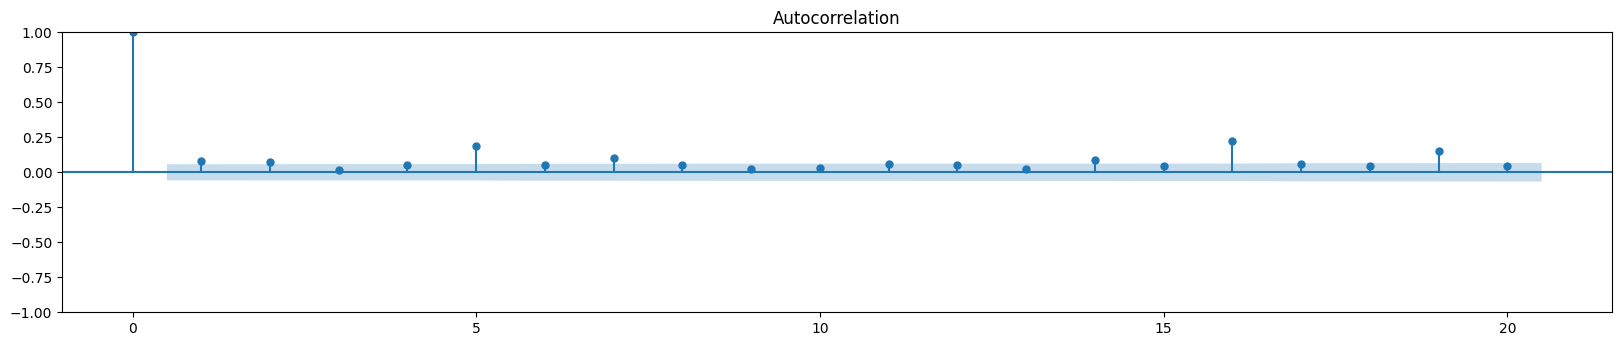

In [49]:
# 정상성
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1= fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts2, lags=20, ax=ax1)

In [50]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts2)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.746492
p-value: 0.003505
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


지금까지의 결과로 보았을 때, ACF 그래프로부터 과거의 강수량이 현재의 강수량에 미칠 영향은 매우 낮음을 확인할 수 있고, p-value 값이 0.05보다 작으므로 정상성을 만족한다고 볼 수 있다.

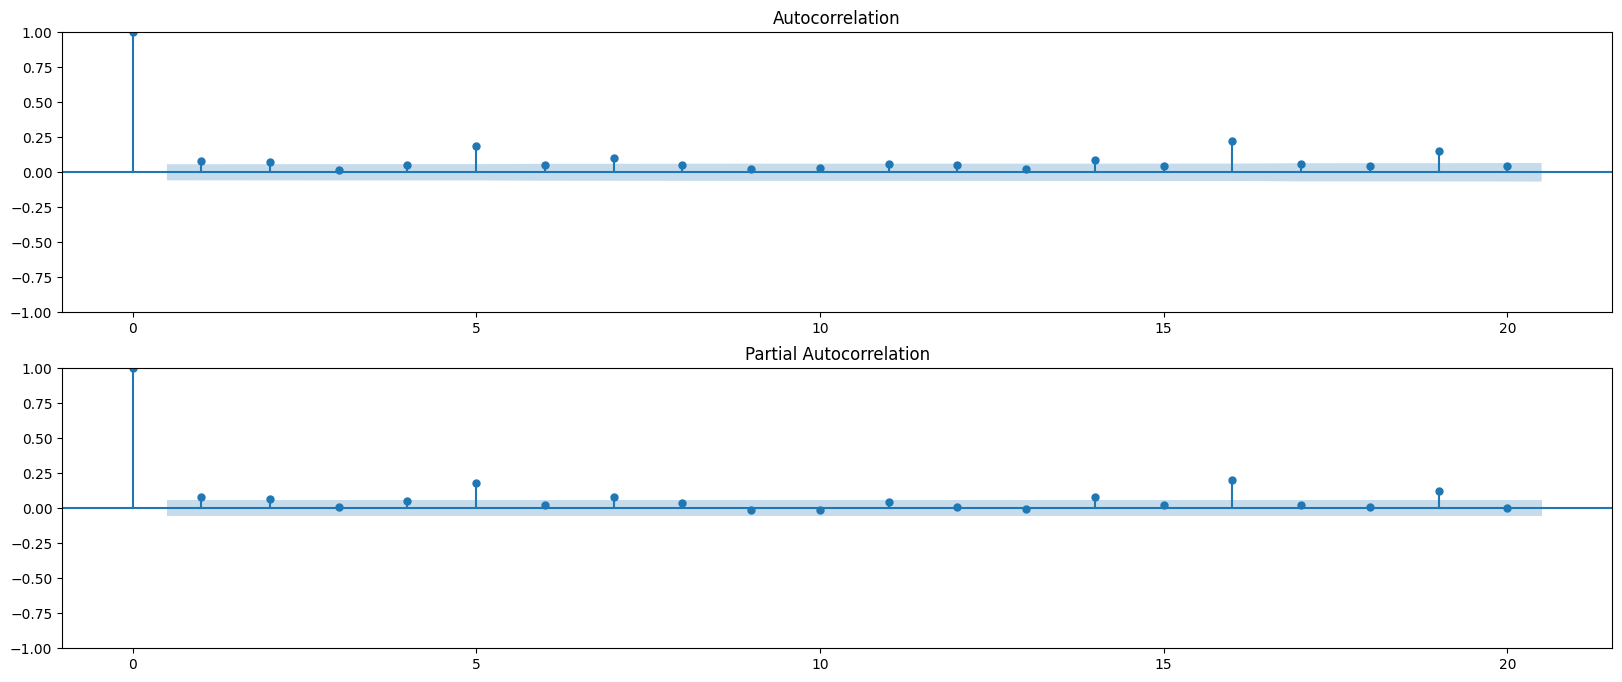

In [51]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts2, lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts2, lags=20, ax=ax2)

ACF와 PACF 결과 그래프로 보았을 때, 자귀회귀 성분을 포함하지 않고, 상관성이 낮아보이므로 p와 q 모두 0으로 설정하였다.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


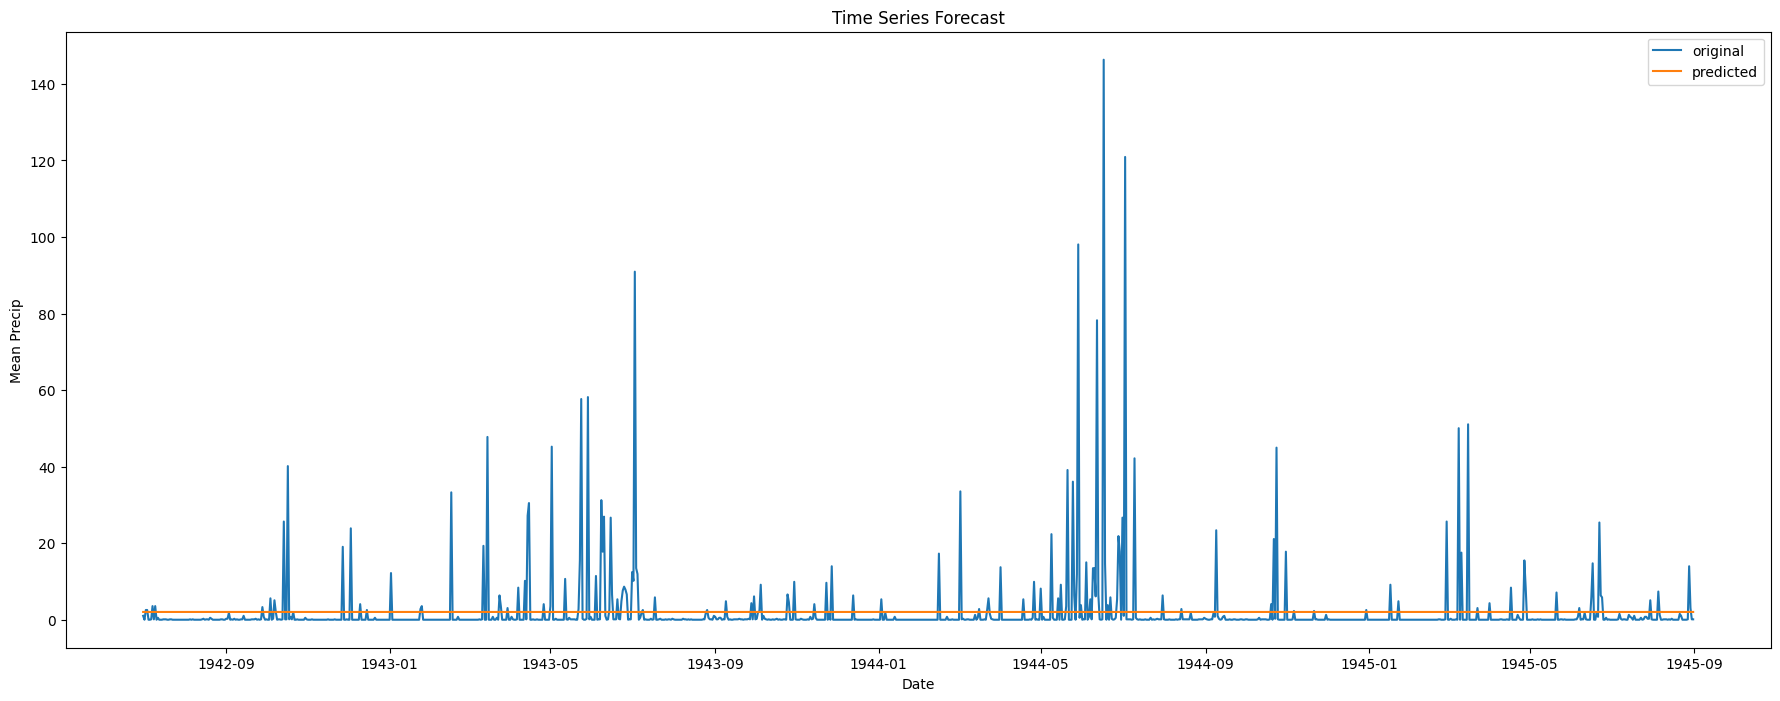

In [55]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 0
d = 0
q = 0

# fit model
model = ARIMA(ts2, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1942, 7, 1)
end_index = datetime(1945, 8, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin2.Date, weather_bin2.Precip, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Precip")
plt.legend()
plt.show()

/tmp/ipykernel_246/4005258782.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


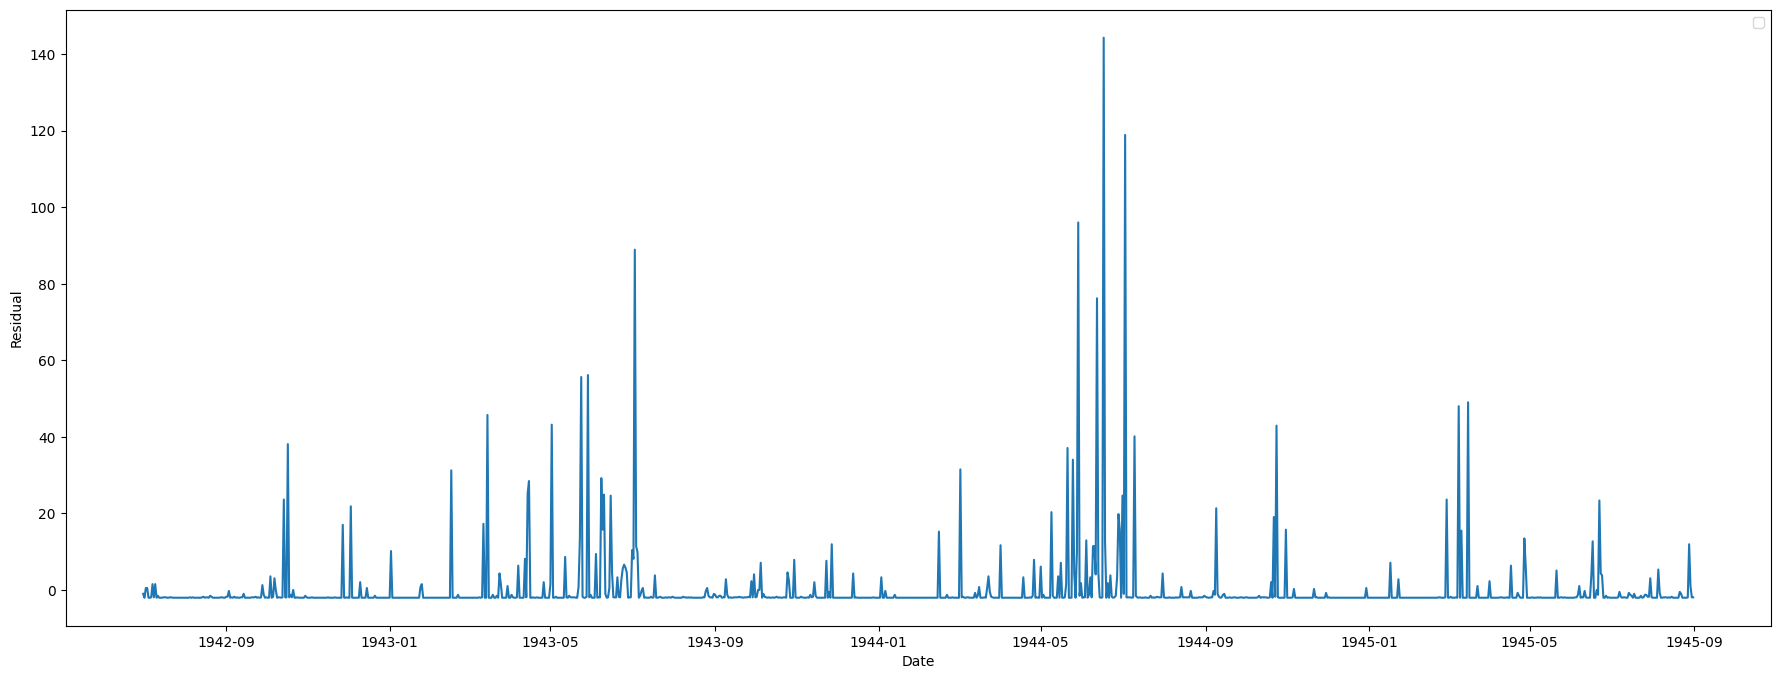

In [56]:
# 잔차 분석
resi = np.array(weather_bin2[weather_bin2.Date >= start_index].Precip) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin2.Date[weather_bin2.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

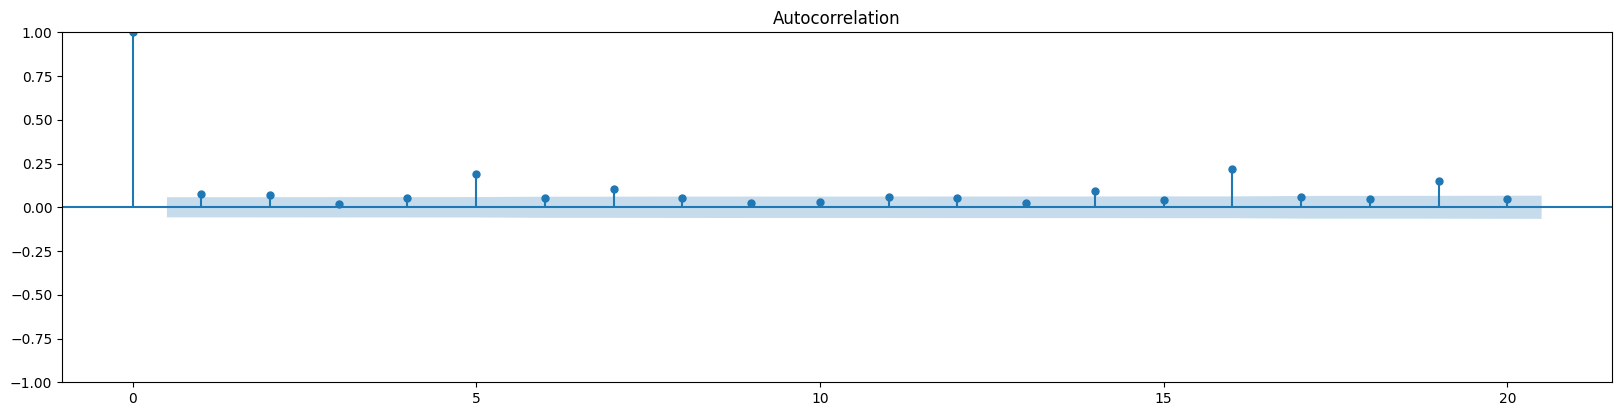

In [57]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [58]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.746492
p-value: 0.003505
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


In [59]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [62]:
scoring(np.array(weather_bin2[weather_bin2.Date >= start_index].Precip), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,-0.0,0.0,9.263,5.633830e+17


ADF test 결과 강수량 데이터의 변동성이라는 특성 때문인지 예측하기 쉽지 않았지만 잔차 분석 결과 정상성은 만족하였기 때문에 모델은 유효하게 설정되었다고 생각한다.<br>
따라서 이 결과는 ARIMA(0, 0, 0) 모델이 ACCRA 지역의 강수량 데이터를 잘 학습하기 여려웠다고 생각한다.

In [63]:
# DLinear
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [71]:
data = ts2.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [72]:
seq_len = 15 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [73]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=5):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [74]:
model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 300

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.025028
Epoch 20, Loss: 0.012895
Epoch 30, Loss: 0.008227
Epoch 40, Loss: 0.006394
Epoch 50, Loss: 0.005638
Epoch 60, Loss: 0.005285
Epoch 70, Loss: 0.005080
Epoch 80, Loss: 0.004941
Epoch 90, Loss: 0.004839
Epoch 100, Loss: 0.004762
Epoch 110, Loss: 0.004705
Epoch 120, Loss: 0.004661
Epoch 130, Loss: 0.004628
Epoch 140, Loss: 0.004601
Epoch 150, Loss: 0.004581
Epoch 160, Loss: 0.004564
Epoch 170, Loss: 0.004551
Epoch 180, Loss: 0.004540
Epoch 190, Loss: 0.004532
Epoch 200, Loss: 0.004524
Epoch 210, Loss: 0.004519
Epoch 220, Loss: 0.004514
Epoch 230, Loss: 0.004510
Epoch 240, Loss: 0.004507
Epoch 250, Loss: 0.004504
Epoch 260, Loss: 0.004502
Epoch 270, Loss: 0.004500
Epoch 280, Loss: 0.004499
Epoch 290, Loss: 0.004497
Epoch 300, Loss: 0.004496


In [77]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )[-seq_len:]

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

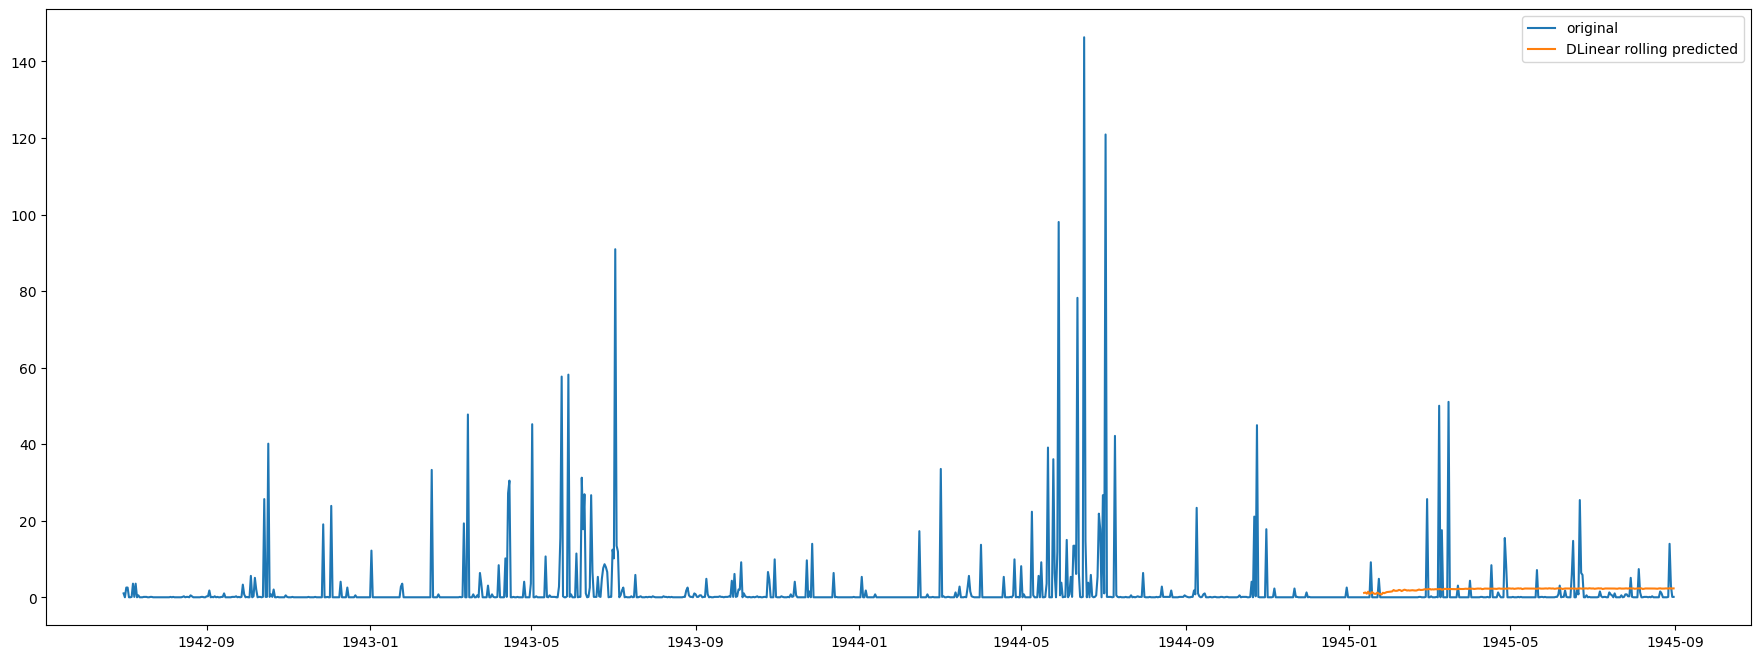

In [78]:
plt.figure(figsize=(22,8))
plt.plot(ts2.index, ts2.values, label="original")

test_dates = ts2.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [79]:
test_start_idx = train_size

y_true = ts2.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(232,) (232,)


,R2,Corr,RMSE,MAPE
0,-1.609,0.034,5.728,6.195332e+17


강수량과 같이 불규칙하고, 이전의 데이터와 상관관계가 뚜렷하지 않은 시계열 데이터에 대한 예측은 상당히 어렵다는 생각을 했다. 모델을 더 개선시키고 싶었지만, 어떤 부분을 수정해야 더 좋은 매개변수를 고를 수 있을 지에 대한 확신이 없어서 어려웠던 것 같다.